In [4]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [5]:
df = sns.load_dataset('iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [6]:
df.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,object


In [ ]:
X = df.select_dtypes(include=[np.number])
X

# ESTANDARIZAMOS LOS DATOS

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled


# APLICANDO KMEANS

In [13]:
k = 3

In [ ]:
kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
kmeans.fit(X_scaled)
labels = kmeans.labels_
labels

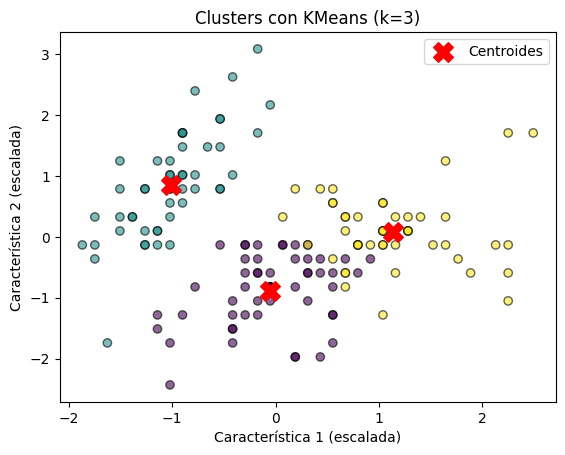

In [16]:
# Visualización de clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroides')
plt.xlabel('Característica 1 (escalada)')
plt.ylabel('Característica 2 (escalada)')
plt.title(f'Clusters con KMeans (k={k})')
plt.legend()
plt.show()

# EVALUAMOS EL MODELO

In [17]:
silhouette_value = silhouette_score(X_scaled,labels)
print(f'Coeficiente de Silueta para k={k} : {silhouette_value}:.4f')

Coeficiente de Silueta para k=3 : 0.45994823920518646:.4f
